In [19]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
  from google.colab import drive

  drive.mount('/content/drive') # load google drive
  os.chdir('/content/drive/My Drive/Thesis_Repository/Final_Google_Drive') # change directory to the current working directory

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Settings

In [20]:
import json
import re
import random
import os
from pathlib import Path
from pprint import pprint

import yaml

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    roc_auc_score,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)


DATA_PATH = Path("./data/stepverify__tutor_turn_only.csv")
FINETUNING_CONFIG_PATH = Path("./configs/finetuning__wce__tutor_turn_only.yaml")
CHECKPOINT_OUT_DIR = "cls_model/weighted_ce/tutor_turn_only/checkpoints"
MODEL_OUT_DIR = "cls_model/weighted_ce/tutor_turn_only/best_model"

MODEL_ID = "FacebookAI/roberta-base"
SEED = 42

INCLUDE_TARGET_TEACHER_TURN = True
TARGET_ONLY = False

# Set Seed
def set_all_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.mps.manual_seed(seed)
    except Exception:
        pass

set_all_seeds(SEED)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2. Functions to load datasets
- load dataframe
- map labels to ids
- tokenize batch
- split datasets
- build dataset objects

In [22]:
# Define tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

In [23]:
# load dataframe
def load_dataframe(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)

# map labels
def label2id_id2label(df: pd.DataFrame, show_stats: bool = True) -> dict:
    """
        map labels to integers.
        converted labels are stored in a new column called 'labels'.
    """
    label_names = sorted(df["label"].unique())

    label2id = {label: i for i, label in enumerate(label_names)}
    id2label = {i: label for label, i in label2id.items()}
    df['labels'] = df['label'].map(label2id).astype(int)

    if show_stats:
        print("[label_names]")
        print(label_names)

        print("\n[label2id]")
        print(label2id)

        print("\n[id2label]")
        print(id2label)

        print("\nEncoded label counts:")
        print(df["label"].value_counts().sort_index())
    return df, label2id, id2label

# split dataset into train, validation, and test sets ( 60:20:20 )
def split_dataset_into_train_val_test(df: pd.DataFrame, show_stats: bool = True) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=SEED,
        stratify=df["labels"],
    )

    train_df, val_df = train_test_split(
        train_df,
        test_size=0.25,
        random_state=SEED,
        stratify=train_df["labels"],
    )

    if show_stats:
        print("[Total size]")
        print("Total:", len(df))

        print("\n[Split sizes]")
        print("train:", len(train_df))
        print("val:", len(val_df))
        print("test:", len(test_df))

        print("\n[Train label counts]")
        print(train_df["labels"].value_counts())

        print("\n[Val label counts]")
        print(val_df["labels"].value_counts())

        print("\n[Test label counts]")
        print(test_df["labels"].value_counts())

    return train_df, val_df, test_df

# tokenize batch
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        add_special_tokens=True, # include <s> and </s> tokens in the beginning and end of the text
        truncation_side="left",  # truncate from the left side
    )

# convert pandas dataframe into a Hugging Face Dataset object
def build_dataset(split_df: pd.DataFrame, tokenizer) -> Dataset:
    ds = Dataset.from_pandas(
        split_df[["text", "labels"]],
        preserve_index=False,
    )

    ds = ds.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"],
    )
    return ds

## 3. Load Data

In [24]:
df = pd.read_csv(DATA_PATH)
df.head()

,text,label
0,tell me your solution,generic
1,how do you know his friend has 12 tyres?,probing
2,"hi claire, talk me through your solution",generic
3,a good start you worked out the ratio was 5 3....,focus
4,walk me thorugh your solution,telling


## 4. Mapping Labels to Integers

In [25]:
df, label2id, id2label = label2id_id2label(df)
label_names = sorted(df["label"].unique())  # variables to use in the test result
num_labels = len(label2id) # variables to use to define a model and the test result

[label_names]
['focus', 'generic', 'probing', 'telling']

[label2id]
{'focus': 0, 'generic': 1, 'probing': 2, 'telling': 3}

[id2label]
{0: 'focus', 1: 'generic', 2: 'probing', 3: 'telling'}

Encoded label counts:
label
focus      536
generic    820
probing    563
telling     63
Name: count, dtype: int64


## 5. Split datasets into train, validation, and test sets

In [26]:
train_df, val_df, test_df = split_dataset_into_train_val_test(df)

[Total size]
Total: 1982

[Split sizes]
train: 1188
val: 397
test: 397

[Train label counts]
labels
1    492
2    337
0    322
3     37
Name: count, dtype: int64

[Val label counts]
labels
1    164
2    113
0    107
3     13
Name: count, dtype: int64

[Test label counts]
labels
1    164
2    113
0    107
3     13
Name: count, dtype: int64


## 6. Build dataset object

In [27]:
train_ds = build_dataset(train_df, tokenizer)
val_ds = build_dataset(val_df, tokenizer)
test_ds = build_dataset(test_df, tokenizer)

print("\n[Dataset columns]")
print("train:", train_ds.column_names)
print("val:", val_ds.column_names)
print("test:", test_ds.column_names)

print("\n[One tokenized example]")
print(train_ds[0].keys())
print(train_ds[0]['input_ids'])
print(tokenizer.decode(train_ds[0]['input_ids'], skip_special_tokens=False))

Map:   0%|          | 0/1188 [00:00<?, ? examples/s]

Map:   0%|          | 0/397 [00:00<?, ? examples/s]

Map:   0%|          | 0/397 [00:00<?, ? examples/s]


[Dataset columns]
train: ['labels', 'input_ids', 'attention_mask']
val: ['labels', 'input_ids', 'attention_mask']
test: ['labels', 'input_ids', 'attention_mask']

[One tokenized example]
dict_keys(['labels', 'input_ids', 'attention_mask'])
[0, 3592, 910, 12839, 6, 64, 47, 1137, 162, 141, 47, 300, 110, 1948, 116, 2]
<s>hi rishi, can you tell me how you got your answer?</s>


## 7. Define a model
7.1. define a metric function

7.2. compuete class weights

7.3. define a trainer that overrides loss function with weighted cross entropy
- define a model, data collator, training arguments, and a trainer that overrides the default cross entropy loss with weighted cross entropy loss

#### 7.1. Metric Function

In [28]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    labels = np.asarray(labels)
    preds = np.argmax(logits, axis=-1)

    probs = torch.softmax(
        torch.tensor(logits, dtype=torch.float32),
        dim=-1,
    ).numpy()

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0,
    )

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_macro,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "matthews_corrcoef": matthews_corrcoef(labels, preds),
    }

    per_precision, per_recall, per_f1, per_support = precision_recall_fscore_support(
        labels,
        preds,
        labels=np.arange(num_labels),
        average=None,
        zero_division=0,
    )

    for i, name in enumerate(label_names):
        label_name = str(name).replace(" ", "_")
        metrics[f"precision_{label_name}"] = per_precision[i]
        metrics[f"recall_{label_name}"] = per_recall[i]
        metrics[f"f1_{label_name}"] = per_f1[i]
        metrics[f"support_{label_name}"] = per_support[i]

    return metrics


#### 7.2. Compute Class Weights
$$ w_c = \frac{N_{\mathrm{samples}}}{N_{\mathrm{classes}} \times N_c} $$

Example)

class 0 (80), class 1 (15), class 2(5), total : 100  $ \Longrightarrow W_0 = \frac{100}{(3 \times 80)} = 0.4167$

In [29]:
def compute_train_class_weights(train_df: pd.DataFrame, show_stats: bool = True) -> torch.Tensor:
    train_unique_labels = sorted(train_df["labels"].unique())
    num_labels = len(train_unique_labels)
    expected_labels = list(range(num_labels))

    if train_unique_labels != expected_labels:
        raise ValueError(
            f"Not all classes exist in train_df. "
            f"expected={expected_labels}, actual={train_unique_labels}. "
            f"Please check stratify in split."
    )

    class_weights_np = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(num_labels),
        y=train_df["labels"].values,
    )

    class_weights = torch.tensor(class_weights_np, dtype=torch.float32)

    if show_stats:
        print("\n[class_weights]")
        for i, weight in enumerate(class_weights.tolist()):
            print(f"{i} / {id2label[i]}: {weight:.4f}")

    return class_weights

In [30]:
class_weights = compute_train_class_weights(train_df)


[class_weights]
0 / focus: 0.9224
1 / generic: 0.6037
2 / probing: 0.8813
3 / telling: 8.0270


#### 7.3. Define a Trainer

Cross Entropy :
$$  \ell_i = -\log \left( \frac{\exp(z_{i,y_i})} {\sum_{j=1}^{C}\exp(z_{i,j})} \right) = - \log p_{i,y_i} \\  
\quad z_{i,j} = \text{the logit for class } j \text{ of sample } i, \quad y_i = \text{true label} $$
$$  $$

- With batch size of B (reduction = mean) :
$$ L_{\mathrm{CE}} = -\frac{1}{B} \sum_{i=1}^{B} \log p_{i,y_i} $$

Weighted Cross Entropy :

$$ \ell_i  = - w_{y_i}\log p_{i,y_i} $$

- With batch size of B (reduction = mean, pytorch implementation) :
$$ L_{\mathrm{WCE}} = -\frac{\sum_{i=1}^{B}w_{y_i}\log p_{i,y_i}}{\sum_{i=1}^{B}w_{y_i}}
$$



pytorch document : https://docs.pytorch.org/docs/2.13/generated/torch.nn.CrossEntropyLoss.html?utm_source=chatgpt.com

mean : The sum of losses in the batch is divided by the sum of class weights in the batch

In [31]:
with FINETUNING_CONFIG_PATH.open("r", encoding="utf-8") as f:
  config = yaml.safe_load(f)

print("[training arguments]")
pprint( config["training_args"], sort_dicts=False, width=100, indent=2)

[training arguments]
{ 'learning_rate': 0.0001,
  'num_train_epochs': 10,
  'warmup_ratio': 0.1,
  'weight_decay': 0.01,
  'per_device_train_batch_size': 16,
  'per_device_eval_batch_size': 16,
  'eval_strategy': 'epoch',
  'save_strategy': 'epoch',
  'load_best_model_at_end': True,
  'metric_for_best_model': 'f1_macro',
  'greater_is_better': True,
  'logging_strategy': 'steps',
  'logging_steps': 10,
  'report_to': 'none'}


In [32]:
# define a model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

# define data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [33]:
# define training arguments
training_args = TrainingArguments(
    output_dir=CHECKPOINT_OUT_DIR,
    seed=SEED,
    **config["training_args"],
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [34]:
class Weighted_CE_Trainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").long()

        outputs = model(**inputs)
        logits = outputs.logits

        weight = class_weights.to(logits.device) # move class weights to the device of the logits
        loss_fn = nn.CrossEntropyLoss(weight=weight)

        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [35]:
trainer = Weighted_CE_Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

## 8. Train the model

In [36]:
train_result = trainer.train()

print("\n[Train result]")
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Matthews Corrcoef,Precision Focus,Recall Focus,F1 Focus,Support Focus,Precision Generic,Recall Generic,F1 Generic,Support Generic,Precision Probing,Recall Probing,F1 Probing,Support Probing,Precision Telling,Recall Telling,F1 Telling,Support Telling
1,1.162967,1.156494,0.632242,0.383944,0.508757,0.456486,0.520168,0.666667,0.018692,0.036364,107,0.929032,0.878049,0.902821,164,0.439331,0.929204,0.596591,113,0.000000,0.000000,0.000000,13
2,1.077049,1.052397,0.614610,0.368552,0.333938,0.453969,0.508835,0.419087,0.943925,0.580460,107,0.916667,0.871951,0.893750,164,0.000000,0.000000,0.000000,113,0.000000,0.000000,0.000000,13
3,1.120908,1.166428,0.609572,0.456405,0.482652,0.516524,0.474002,0.321429,0.084112,0.133333,107,0.984615,0.780488,0.870748,164,0.476415,0.893805,0.621538,113,0.148148,0.307692,0.200000,13
4,0.815117,1.128769,0.662469,0.423132,0.529387,0.488188,0.550165,0.478261,0.925234,0.630573,107,0.870056,0.939024,0.903226,164,0.769231,0.088496,0.158730,113,0.000000,0.000000,0.000000,13
5,0.680013,1.262015,0.642317,0.444981,0.554467,0.499993,0.519139,0.700000,0.065421,0.119658,107,0.905660,0.878049,0.891641,164,0.478873,0.902655,0.625767,113,0.133333,0.153846,0.142857,13
6,0.791369,1.172576,0.712846,0.572890,0.580455,0.568695,0.573831,0.603604,0.626168,0.614679,107,0.906250,0.884146,0.895062,164,0.589744,0.610619,0.600000,113,0.222222,0.153846,0.181818,13
7,0.475205,1.267102,0.722922,0.564181,0.592333,0.559838,0.586186,0.650485,0.626168,0.638095,107,0.884848,0.890244,0.887538,164,0.584000,0.646018,0.613445,113,0.250000,0.076923,0.117647,13
8,0.535515,1.294946,0.727960,0.588102,0.599820,0.582781,0.596783,0.596491,0.635514,0.615385,107,0.917197,0.878049,0.897196,164,0.635593,0.663717,0.649351,113,0.250000,0.153846,0.190476,13
9,0.335163,1.456113,0.712846,0.571988,0.585633,0.566327,0.572730,0.621053,0.551402,0.584158,107,0.885542,0.896341,0.890909,164,0.585938,0.663717,0.622407,113,0.250000,0.153846,0.190476,13
10,0.310230,1.491404,0.732997,0.597037,0.623079,0.588515,0.603238,0.613445,0.682243,0.646018,107,0.893750,0.871951,0.882716,164,0.651786,0.646018,0.648889,113,0.333333,0.153846,0.210526,13


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[Train result]
TrainOutput(global_step=750, training_loss=0.760867794195811, metrics={'train_runtime': 199.9991, 'train_samples_per_second': 59.4, 'train_steps_per_second': 3.75, 'total_flos': 295254961516320.0, 'train_loss': 0.760867794195811, 'epoch': 10.0})


## 9. Test Evaluation

In [37]:
def safe_binary_auc(y_true, y_score):
    # to compute auc, there must be both positive and negative samples
    # scikit-learn roc_auc_score uses FPR TPR to plot ROC curve and compute auc by changing the decision threshold.
    # If there is no positives -> TPR cannot be computed ( TP / TP + FN, TP + FN = 0 )
    # If there is no negatives -> FPR cannot be computed ( FP / FP + TN, FP + TN = 0 )
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    if np.unique(y_true).size < 2:
        return np.nan

    return roc_auc_score(y_true, y_score)


test_output = trainer.predict(test_ds)

test_logits = np.asarray(test_output.predictions)
test_probs = 1.0 / (1.0 + np.exp(-test_logits))
test_pred = np.argmax(test_probs, axis=-1)
test_true = np.asarray(test_output.label_ids)


print("\n[test classification report]")
print(
    classification_report(
        test_true,
        test_pred,
        labels=np.arange(num_labels),
        target_names=label_names,
        zero_division=0,
    )
)

print("\n[test support]")
print(
    pd.DataFrame(
        {
            "label": label_names,
            "support": [(test_true == i).sum() for i in range(num_labels)],
        }
    )
)

print("\ntest_accuracy =", round(accuracy_score(test_true, test_pred), 4))
print("test_macro_f1 =", round(f1_score(test_true, test_pred, average="macro"), 4))

print("\n[test matthews_corrcoef]")
print(matthews_corrcoef(test_true, test_pred))



y_true_ovr = np.eye(num_labels, dtype=np.int64)[test_true]
test_auc_per_class = {}
valid_auc = []

for i, name in enumerate(label_names):
    auc_i = safe_binary_auc(y_true_ovr[:, i], test_probs[:, i])
    test_auc_per_class[name] = auc_i
    if not np.isnan(auc_i):
        valid_auc.append(auc_i)

print("\n[test per-class auc]")
for name, auc_i in test_auc_per_class.items():
    print(name, "=", None if np.isnan(auc_i) else round(float(auc_i), 4))

print("\ntest_auc_macro_ovr =", None if not valid_auc else round(float(np.mean(valid_auc)), 4))




[test classification report]
              precision    recall  f1-score   support

       focus       0.56      0.59      0.57       107
     generic       0.95      0.89      0.92       164
     probing       0.59      0.63      0.61       113
     telling       0.40      0.31      0.35        13

    accuracy                           0.72       397
   macro avg       0.62      0.60      0.61       397
weighted avg       0.72      0.72      0.72       397


[test support]
     label  support
0    focus      107
1  generic      164
2  probing      113
3  telling       13

test_accuracy = 0.7154
test_macro_f1 = 0.6121

[test matthews_corrcoef]
0.5795826290128037

[test per-class auc]
focus = 0.7779
generic = 0.9418
probing = 0.8486
telling = 0.7677

test_auc_macro_ovr = 0.834


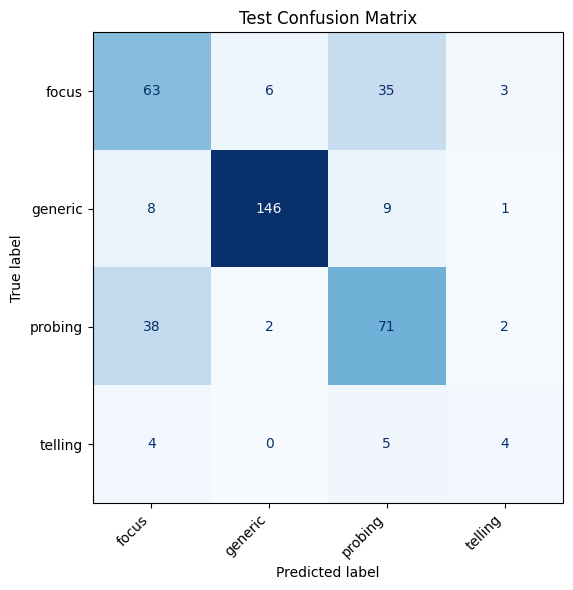

In [38]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(true_labels, pred_labels, num_labels, label_names, title="Test Confusion Matrix"):
    # Calculate confusion matrix
    cm = confusion_matrix(true_labels, pred_labels, labels=np.arange(num_labels))

    # Visualize confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(test_true, test_pred, num_labels, label_names)

## 10. Save Model

In [39]:
trainer.save_model(MODEL_OUT_DIR)
tokenizer.save_pretrained(MODEL_OUT_DIR)

print("\nSaved model to ", MODEL_OUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved model to  cls_model/weighted_ce/tutor_turn_only/best_model


## 11. Disconnect Colab Session (if applicable)

In [40]:
import os
import platform
import shutil
import subprocess

import psutil

def run_command(command: list[str]) -> str | None:
    try:
        result = subprocess.run(
            command,
            capture_output=True,
            text=True,
            check=True,
        )
        return result.stdout.strip()

    except (FileNotFoundError, subprocess.CalledProcessError):
        return None


def get_colab_machine_info() -> dict:
    # CPU Information
    cpu_model = run_command(
        ["bash", "-c", "lscpu | grep 'Model name' | cut -d ':' -f 2-"]
    )

    # GPU Information
    gpu_info = run_command(
        [
            "nvidia-smi",
            "--query-gpu=name,memory.total,driver_version",
            "--format=csv,noheader",
        ]
    )

    # 메모리 및 디스크
    memory = psutil.virtual_memory()
    disk = shutil.disk_usage("/")

    return {
        "system": platform.system(),
        "machine_architecture": platform.machine(),
        "cpu_model": cpu_model.strip() if cpu_model else "Unknown",
        "cpu_count": os.cpu_count(),
        "ram_total_gb": round(memory.total / 1024**3, 2),
        "ram_available_gb": round(memory.available / 1024**3, 2),
        "disk_total_gb": round(disk.total / 1024**3, 2),
        "disk_free_gb": round(disk.free / 1024**3, 2),
        "gpu": gpu_info or "gpu not available",
    }

In [42]:
if IN_COLAB:

  machine_info = get_colab_machine_info()

  for key, value in machine_info.items():
      print(f"{key}: {value}")

  with open("/proc/uptime", "r") as file:
    uptime_seconds = float(file.readline().split()[0])

  runtime_minutes = uptime_seconds / 60
  print(f"Current runtime: {runtime_minutes:.1f}분")

  from google.colab import runtime
  runtime.unassign()


system: Linux
machine_architecture: x86_64
cpu_model: AMD EPYC 9B45
cpu_count: 48
ram_total_gb: 176.88
ram_available_gb: 170.73
disk_total_gb: 235.68
disk_free_gb: 173.98
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition, 97887 MiB, 580.82.07
Current runtime: 19.0분
